<a href="https://colab.research.google.com/github/AntoinePERRETTE/ETRS923-IA-et-Objets-Connect-s/blob/Test_Antoine/ETRS923.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/AntoinePERRETTE/ETRS923-IA-et-Objets-Connect-s

Cloning into 'ETRS923-IA-et-Objets-Connect-s'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 32 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 1.44 MiB | 16.93 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
# Add the path for the Python code for your project folder
import sys
sys.path.append('/content/ETRS923-IA-et-Objets-Connect-s/TP_1')

In [ ]:
# Connect the Matplotlib library to visualize images in the model from the your folder
from IPython.display import Image
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans']
matplotlib.rcParams['text.usetex'] = False

#**TP 1 : Problème MNIST**
##1. Choix de la fonction d'activation
###a - Réseau simple de deux couches avec la fonction d'activation softmax :

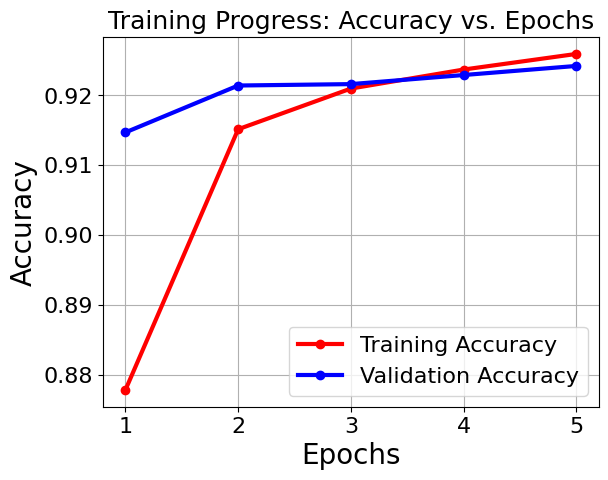

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9259 - loss: 0.2670 - val_accuracy: 0.9242 - val_loss: 0.2710
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9242 - loss: 0.2710
Test accuracy: 0.9242

--- Model Summary (Neurons and Synapses) ---
Layer: dense_5 (Dense), Parameters: 7850, Neurons: 10, Weights: 7840, Bias: 10, Calculated Synapses (Weights + Bias): 7850

Total Neurons (approx, mainly from Dense/RNN): 10
Total Synapses (Total Trainable Parameters): 7850


In [ ]:
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from callbackPlots import AccuracyPlotCallback
from callbackPlots import count_neurons_and_synapses
import numpy as np
import random

np.random.seed(20)
tf.random.set_seed(20)
random.seed(20)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"Training set size: {x_train.shape}, Test set size: {x_test.shape}")

# Flatten images (28x28 -> 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Build a simple softmax classifier
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='softmax', input_shape=(784,)),
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Create the callback instance
plot_callback = AccuracyPlotCallback()

# Debugging: Print if the callback is created correctly
print(f"Callback created: {plot_callback}")

# Train the model with the callback
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test), callbacks=[plot_callback])

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Save the model architecture as a PNG file
plot_model(model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True, dpi=300)

# Call the function
count_neurons_and_synapses(model)

###b - Réseau de deux couches cachés, et ReLu comme fonction d'activation :

Taille du jeu d'entraînement : (60000, 784), Test : (10000, 784)

=== Comparaison des Optimiseurs pour le Modèle 1 (Classification Softmax) ===

--> Entraînement du Modèle 1 avec l'optimiseur : ADAM


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[ADAM] Précision sur le jeu de test : 0.9768 | Perte : 0.1113

--> Entraînement du Modèle 1 avec l'optimiseur : SGD
[SGD] Précision sur le jeu de test : 0.9717 | Perte : 0.0900

--> Entraînement du Modèle 1 avec l'optimiseur : RMSPROP
[RMSPROP] Précision sur le jeu de test : 0.9794 | Perte : 0.1783

--> Entraînement du Modèle 1 avec l'optimiseur : ADAGRAD
[ADAGRAD] Précision sur le jeu de test : 0.9391 | Perte : 0.2127


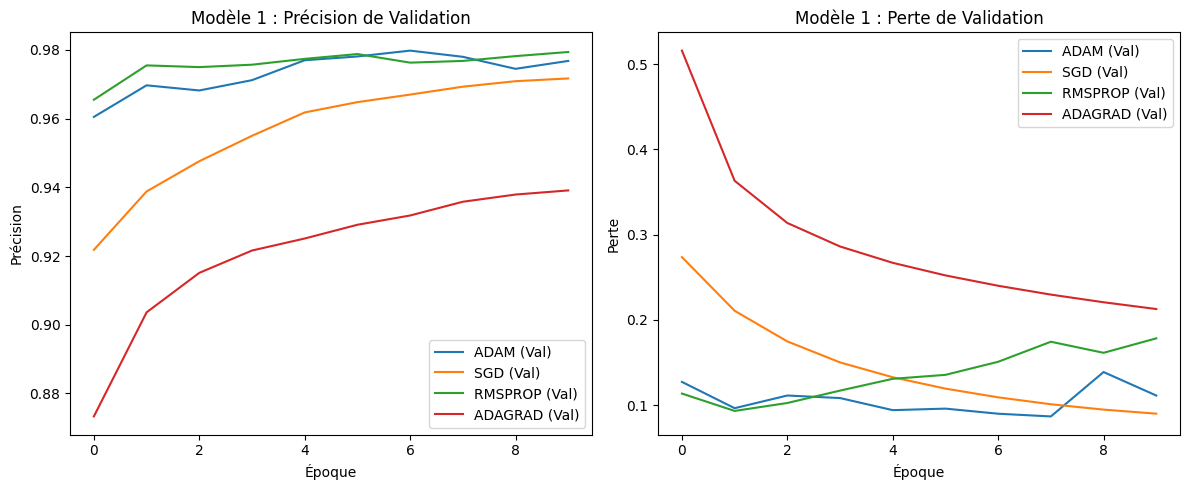


=== Comparaison des Optimiseurs pour le Modèle 2 (Régression Logits) ===

--> Entraînement du Modèle 2 avec l'optimiseur : ADAM
[ADAM] MAE sur le jeu de test : 0.2020 | MSE (Perte) : 0.3107

--> Entraînement du Modèle 2 avec l'optimiseur : SGD
[SGD] MAE sur le jeu de test : 0.2698 | MSE (Perte) : 0.3699

--> Entraînement du Modèle 2 avec l'optimiseur : RMSPROP
[RMSPROP] MAE sur le jeu de test : 0.2105 | MSE (Perte) : 0.3607

--> Entraînement du Modèle 2 avec l'optimiseur : ADAGRAD
[ADAGRAD] MAE sur le jeu de test : 0.6393 | MSE (Perte) : 0.9171


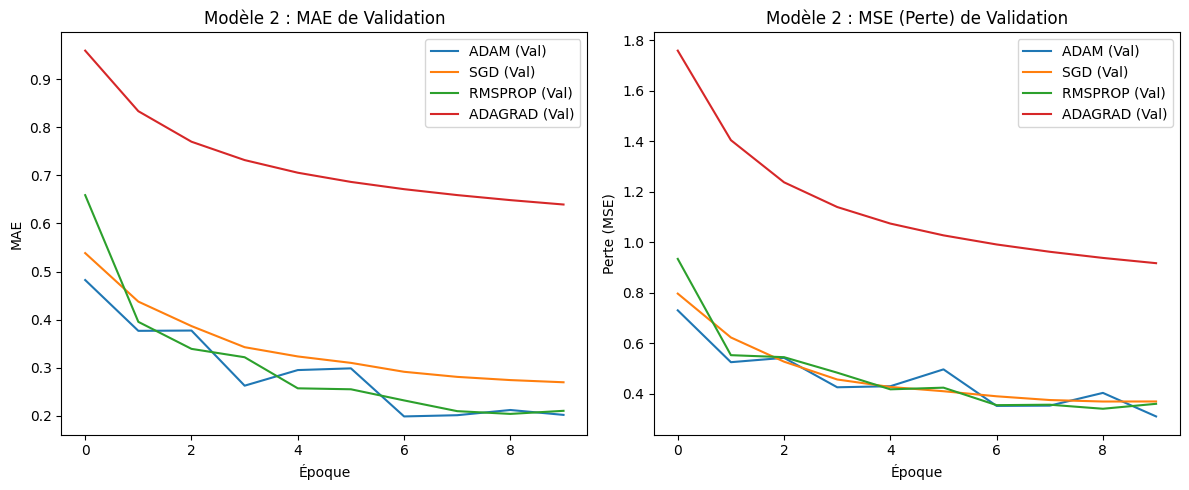


Les résultats comparatifs ont été enregistrés dans 'resultats_tests.txt'


In [26]:
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from callbackPlots import count_neurons_and_synapses
import numpy as np
import random
import matplotlib.pyplot as plt

# Fixer les graines pour la reproductibilité
np.random.seed(20)
tf.random.set_seed(20)
random.seed(20)

# Charger les données MNIST
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Normaliser et aplatir les données
x_train = (x_train_raw / 255.0).reshape(-1, 784)
x_test = (x_test_raw / 255.0).reshape(-1, 784)

print(f"Taille du jeu d'entraînement : {x_train.shape}, Test : {x_test.shape}")

# Préparer les étiquettes pour le Modèle 1 (One-Hot Encoding)
y_train_onehot = tf.keras.utils.to_categorical(y_train_raw, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test_raw, 10)

# Préparer les étiquettes pour le Modèle 2 (Un seul neurone de sortie : étiquettes continues de 0.0 à 9.0)
y_train_single = y_train_raw.astype(np.float32).reshape(-1, 1)
y_test_single = y_test_raw.astype(np.float32).reshape(-1, 1)

# Liste des optimiseurs à tester
optimizers_to_test = ['adam', 'sgd', 'rmsprop', 'adagrad']

# Listes pour stocker les logs et historiques
log_lines = []
histories_model1 = {}
histories_model2 = {}

def log_print(message):
    print(message)
    log_lines.append(message)

# ========================================== #
# TEST DES OPTIMISEURS POUR LE MODÈLE 1      #
# ========================================== #
log_print("\n=== Comparaison des Optimiseurs pour le Modèle 1 (Classification Softmax) ===")

for opt in optimizers_to_test:
    log_print(f"\n--> Entraînement du Modèle 1 avec l'optimiseur : {opt.upper()}")

    # Recréer le modèle pour chaque test
    model1 = tf.keras.Sequential([
        tf.keras.layers.Dense(392, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(196, activation='relu'),
        tf.keras.layers.Dense(98, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])

    model1.compile(optimizer=opt,
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

    history = model1.fit(x_train, y_train_onehot, epochs=10, batch_size=32,
                         validation_data=(x_test, y_test_onehot), verbose=0)

    histories_model1[opt] = history.history
    test_loss1, test_acc1 = model1.evaluate(x_test, y_test_onehot, verbose=0)
    log_print(f"[{opt.upper()}] Précision sur le jeu de test : {test_acc1:.4f} | Perte : {test_loss1:.4f}")

# Tracer les courbes comparatives pour le Modèle 1
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for opt in optimizers_to_test:
    plt.plot(histories_model1[opt]['val_accuracy'], label=f'{opt.upper()} (Val)')
plt.title('Modèle 1 : Précision de Validation')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()

plt.subplot(1, 2, 2)
for opt in optimizers_to_test:
    plt.plot(histories_model1[opt]['val_loss'], label=f'{opt.upper()} (Val)')
plt.title('Modèle 1 : Perte de Validation')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()
plt.tight_layout()
plt.savefig('model1_optimizers_comparison.png', dpi=300)
plt.show()
plt.close()

# ========================================== #
# TEST DES OPTIMISEURS POUR LE MODÈLE 2      #
# ========================================== #
log_print("\n=== Comparaison des Optimiseurs pour le Modèle 2 (Régression Logits) ===")

for opt in optimizers_to_test:
    log_print(f"\n--> Entraînement du Modèle 2 avec l'optimiseur : {opt.upper()}")

    # Recréer le modèle pour chaque test
    model2 = tf.keras.Sequential([
        tf.keras.layers.Dense(392, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(196, activation='relu'),
        tf.keras.layers.Dense(98, activation='relu'),
        tf.keras.layers.Dense(1, activation=None),
    ])

    model2.compile(optimizer=opt,
                   loss='mean_squared_error',
                   metrics=['mae'])

    history = model2.fit(x_train, y_train_single, epochs=10, batch_size=32,
                         validation_data=(x_test, y_test_single), verbose=0)

    histories_model2[opt] = history.history
    test_loss2, test_mae2 = model2.evaluate(x_test, y_test_single, verbose=0)
    log_print(f"[{opt.upper()}] MAE sur le jeu de test : {test_mae2:.4f} | MSE (Perte) : {test_loss2:.4f}")

# Tracer les courbes comparatives pour le Modèle 2
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for opt in optimizers_to_test:
    plt.plot(histories_model2[opt]['val_mae'], label=f'{opt.upper()} (Val)')
plt.title('Modèle 2 : MAE de Validation')
plt.xlabel('Époque')
plt.ylabel('MAE')
plt.legend()

plt.subplot(1, 2, 2)
for opt in optimizers_to_test:
    plt.plot(histories_model2[opt]['val_loss'], label=f'{opt.upper()} (Val)')
plt.title('Modèle 2 : MSE (Perte) de Validation')
plt.xlabel('Époque')
plt.ylabel('Perte (MSE)')
plt.legend()
plt.tight_layout()
plt.savefig('model2_optimizers_comparison.png', dpi=300)
plt.show()
plt.close()

# Écrire les résultats écrits dans un fichier texte
with open("resultats_tests.txt", "w") as f:
    f.write("\n".join(log_lines))
print("\nLes résultats comparatifs ont été enregistrés dans 'resultats_tests.txt'")

###c - Réseau de deux couches cachés, et tanh comme fonction d'activation :

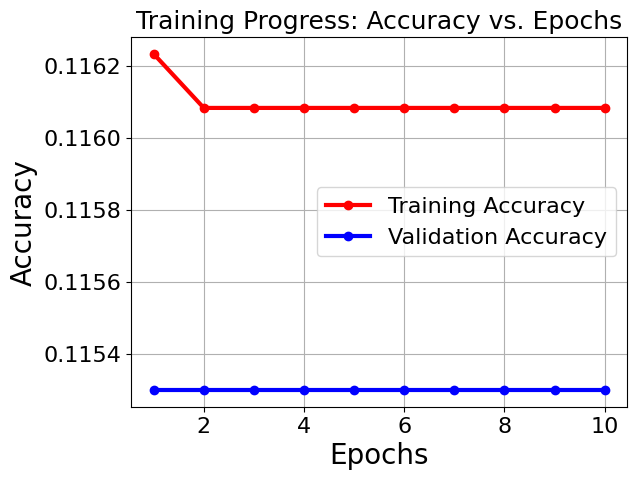

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1161 - loss: 8.0614 - val_accuracy: 0.1153 - val_loss: 8.0188
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1153 - loss: 8.0188
Test accuracy: 0.1153

--- Model Summary (Neurons and Synapses) ---
Layer: dense_34 (Dense), Parameters: 307720, Neurons: 392, Weights: 307328, Bias: 392, Calculated Synapses (Weights + Bias): 307720
Layer: dense_35 (Dense), Parameters: 77028, Neurons: 196, Weights: 76832, Bias: 196, Calculated Synapses (Weights + Bias): 77028
Layer: dense_36 (Dense), Parameters: 19306, Neurons: 98, Weights: 19208, Bias: 98, Calculated Synapses (Weights + Bias): 19306
Layer: dense_37 (Dense), Parameters: 990, Neurons: 10, Weights: 980, Bias: 10, Calculated Synapses (Weights + Bias): 990

Total Neurons (approx, mainly from Dense/RNN): 696
Total Synapses (Total Trainable Parameters): 405044


In [ ]:
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from callbackPlots import AccuracyPlotCallback
from callbackPlots import count_neurons_and_synapses
import numpy as np
import random

np.random.seed(20)
tf.random.set_seed(20)
random.seed(20)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"Training set size: {x_train.shape}, Test set size: {x_test.shape}")

# Flatten images (28x28 -> 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Build a simple tanh classifier
model = tf.keras.Sequential([
    tf.keras.layers.Dense(392, activation='tanh', input_shape=(784,)),
    tf.keras.layers.Dense(196, activation='tanh', input_shape=(392,)),
    tf.keras.layers.Dense(98, activation='tanh', input_shape=(196,)),
    tf.keras.layers.Dense(10, activation='tanh', input_shape=(98,)),
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Create the callback instance
plot_callback = AccuracyPlotCallback()

# Debugging: Print if the callback is created correctly
print(f"Callback created: {plot_callback}")

# Train the model with the callback
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test), callbacks=[plot_callback])

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Save the model architecture as a PNG file
plot_model(model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True, dpi=300)

# Call the function
count_neurons_and_synapses(model)

###d - Réseau de deux couches cachés, et sigmoid comme fonction d'activation :

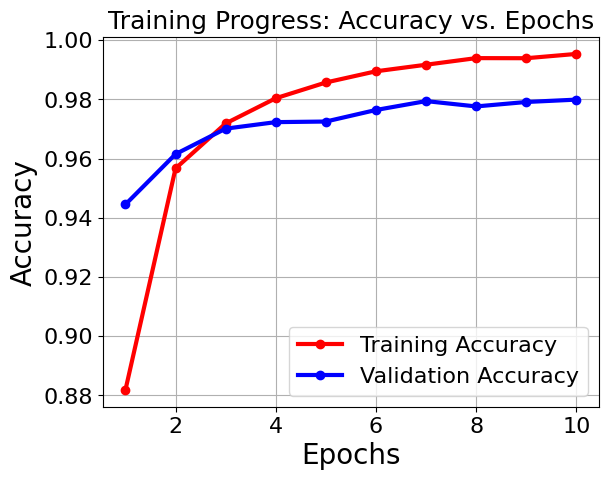

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9953 - loss: 0.0144 - val_accuracy: 0.9799 - val_loss: 0.0824
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9799 - loss: 0.0824
Test accuracy: 0.9799

--- Model Summary (Neurons and Synapses) ---
Layer: dense_22 (Dense), Parameters: 307720, Neurons: 392, Weights: 307328, Bias: 392, Calculated Synapses (Weights + Bias): 307720
Layer: dense_23 (Dense), Parameters: 77028, Neurons: 196, Weights: 76832, Bias: 196, Calculated Synapses (Weights + Bias): 77028
Layer: dense_24 (Dense), Parameters: 19306, Neurons: 98, Weights: 19208, Bias: 98, Calculated Synapses (Weights + Bias): 19306
Layer: dense_25 (Dense), Parameters: 990, Neurons: 10, Weights: 980, Bias: 10, Calculated Synapses (Weights + Bias): 990

Total Neurons (approx, mainly from Dense/RNN): 696
Total Synapses (Total Trainable Parameters): 405044


In [ ]:
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from callbackPlots import AccuracyPlotCallback
from callbackPlots import count_neurons_and_synapses
import numpy as np
import random

#bite
np.random.seed(20)
tf.random.set_seed(20)
random.seed(20)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"Training set size: {x_train.shape}, Test set size: {x_test.shape}")

# Flatten images (28x28 -> 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Build a simple sigmoid classifier
model = tf.keras.Sequential([
    tf.keras.layers.Dense(392, activation='sigmoid', input_shape=(784,)),
    tf.keras.layers.Dense(196, activation='sigmoid', input_shape=(392,)),
    tf.keras.layers.Dense(98, activation='sigmoid', input_shape=(196,)),
    tf.keras.layers.Dense(10, activation='sigmoid', input_shape=(98,)),
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',###################################################################
              metrics=['accuracy'])

# Create the callback instance
plot_callback = AccuracyPlotCallback()

# Debugging: Print if the callback is created correctly
print(f"Callback created: {plot_callback}")

# Train the model with the callback
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test), callbacks=[plot_callback])

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Save the model architecture as a PNG file
plot_model(model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True, dpi=300)

# Call the function
count_neurons_and_synapses(model)